In [99]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

In [100]:
base = os.getcwd()
path1 = Path(base) / 'img' / '20260710_153257.jpg'

os.path.isfile(path1)

True

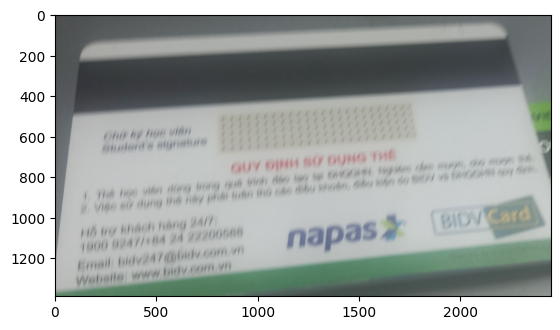

In [101]:
img1 = cv2.imread(path1)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.imshow(img1)

In [102]:
path2 = Path(base) / 'img' / '20260710_154051.jpg'

os.path.isfile(path2)

True

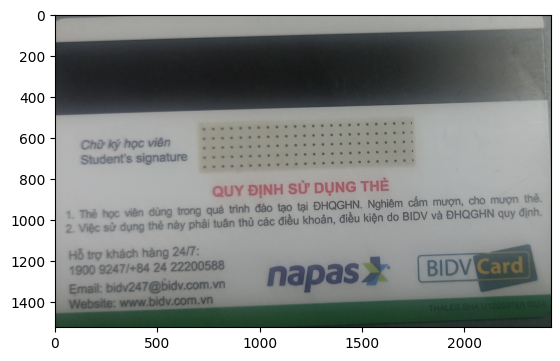

In [103]:
img2 = cv2.imread(path2)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img2)

In [104]:
def is_blurry(img, threshold=95.0):
    (h, w) = img.shape[:2]
    width = 800
    r = width / float(w)
    dim = (width, int(h * r))
    resized = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    # Laplacian operator to calculate the variance of the image
    fm = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    if fm < threshold:
        return True, fm
    return False, fm

True : Ảnh bị mờ


False : Ảnh rõ nét

In [105]:
t1 = is_blurry(img1)
t1

(True, np.float64(26.804387086998805))

In [106]:
t2 = is_blurry(img2)
t2

(False, np.float64(156.38714178753895))